In [1]:
ref = -149.16295032

In [2]:
ref*4

-596.65180128

In [6]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

def fit_fp_decay(beta, energy, d_energy, save_plot=False):
    # fit the exponential energy decaying of free projection energy

    def exp_plateau(beta, E_inf, A, beta_c):
        return E_inf + A * np.exp(-beta / beta_c)

    # Initial guesses: E_inf ~ last points, A ~ E(0)-E_inf, beta_c ~ 1
    p0 = [energy[-1], energy[0]-energy[-1], 1]

    popt, pcov = curve_fit(exp_plateau, beta, energy, p0=p0,
                        sigma=d_energy, absolute_sigma=True,
                        maxfev=10000)

    E_inf, A, gamma = popt
    perr = np.sqrt(np.diag(pcov))
    dE_inf, dA, dgamma = perr

    # Report
    print("=" * 80)
    print("  Exponential-Energy Cooling fit:  E(beta) = E_inf + A exp(-Gamma*beta)")
    print("=" * 80)
    print(f"  E_inf   = {E_inf:.6f} ± {dE_inf:.6f}")
    print(f"  A       = {A:.6f} ± {dA:.6f}")
    print(f"  Gamma   = {gamma:.4f} ± {dgamma:.4f}")
    print(f"  System cooled to about 37% initial Energy gap at beta = {1/gamma:.4f} a.u. (1/Gamma)")
    print(f"  System considered fully cooled at about beta = [{3/gamma:.4f}, {5/gamma:.4f}] a.u.")
    print("=" * 80)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

    beta_fine = np.linspace(0, beta[-1] * 1.05, 300)
    ax1.errorbar(beta, energy, yerr=d_energy, fmt='o', ms=4, capsize=3,
                color='C0', label='Data')
    ax1.plot(beta_fine, exp_plateau(beta_fine, *popt), '-', color='C1',
            label=rf'Fit: E($\beta$)={E_inf:.2f}+{A:.2f}exp(-{gamma:.2f}$\beta$)')
    ax1.axhline(E_inf, ls='--', color='C2', alpha=0.7,
                label=rf' $E_\infty$={E_inf:.5f}±{dE_inf:.5f}')
    ax1.fill_between(beta_fine, E_inf - dE_inf, E_inf + dE_inf,
                    color='C2', alpha=0.15)
    ax1.set_ylabel('Energy')
    ax1.set_title('Imaginary-time cooling curve')
    ax1.legend(fontsize=9)

    # Residuals
    residuals = (energy - exp_plateau(beta, *popt)) / d_energy
    ax2.errorbar(beta, residuals, yerr=1, fmt='o', ms=4, capsize=3, color='C0')
    ax2.axhline(0, ls='-', color='gray', lw=0.8)
    ax2.axhline(2, ls=':', color='gray', lw=0.6)
    ax2.axhline(-2, ls=':', color='gray', lw=0.6)
    ax2.set_xlabel(r'Imaginary time  $\beta$')
    ax2.set_ylabel(r'Residual ($\sigma$)')
    plt.tight_layout()
    if save_plot:
        plt.savefig('./fp_energy_decay.png', dpi=150)
    plt.show()
    #plt.close(fig) # don't show plot

    return E_inf, dE_inf

  Exponential-Energy Cooling fit:  E(beta) = E_inf + A exp(-Gamma*beta)
  E_inf   = -596.517881 ± 48.827291
  A       = -0.133211 ± 48.827637
  Gamma   = 464.5355 ± 170968.8976
  System cooled to about 37% initial Energy gap at beta = 0.0022 a.u. (1/Gamma)
  System considered fully cooled at about beta = [0.0065, 0.0108] a.u.


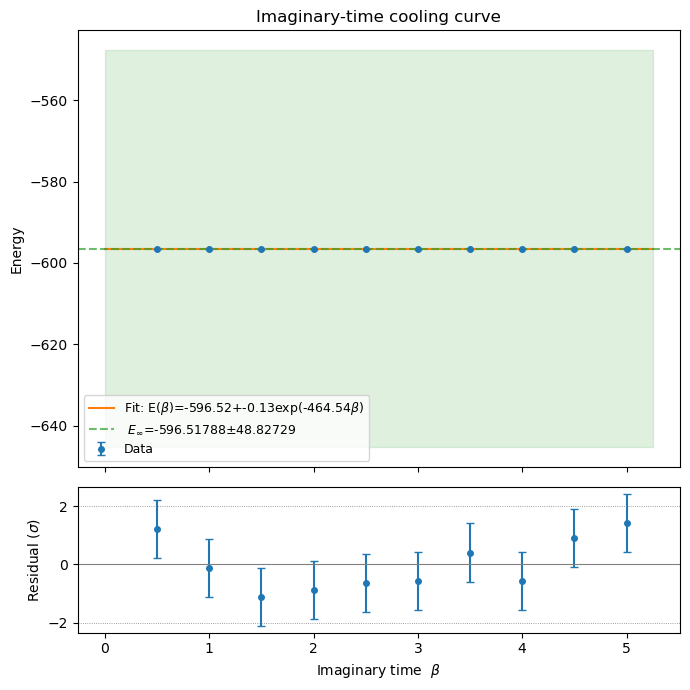

(np.float64(-596.5178814920167), np.float64(48.827291047064485))

In [7]:
data = '''
  0.00  -596.64115   0.00041    285.69 
  0.50  -596.64948   0.00122    285.69 
  1.00  -596.65100   0.00153    285.69 
  1.50  -596.65277   0.00188    285.69 
  2.00  -596.65247   0.00220    285.69 
  2.50  -596.65211   0.00266    285.69 
  3.00  -596.65197   0.00299    285.69 
  3.50  -596.64889   0.00296    285.69 
  4.00  -596.65201   0.00360    285.69 
  4.50  -596.64636   0.00379    285.69 
  5.00  -596.64318   0.00454    285.69 
'''
arr = np.loadtxt(data.strip().splitlines())
tau = arr[1:, 0]
energy = arr[1:, 1]
d_energy = arr[1:, 2]
fit_fp_decay(tau, energy, d_energy, save_plot=False)

In [8]:
tau = arr[1:, 0]
energy = arr[1:, 1]
d_energy = arr[1:, 2]

def exp_plateau(tau, E_inf, A, beta_c):
    return E_inf + A * np.exp(-tau / beta_c)

# Initial guesses: E_inf ~ last E, A ~ E(0)-E_inf, beta_c ~ 1/0.3 ≈ 3.3
p0 = [energy[-1], energy[0] - energy[-1], 1.0]

popt, pcov = curve_fit(exp_plateau, tau, energy, p0=p0,
                       sigma=d_energy, absolute_sigma=True,
                       maxfev=10000)

E_inf, A, beta_c = popt
perr = np.sqrt(np.diag(pcov))
dE_inf, dA, dbeta_c = perr

print("=" * 80)
print("  Exponential-Energy Decaying Fit:  E(beta) = E_inf + A exp(-beta/beta_c) ")
print("=" * 80)
print(f"  E_inf   = {E_inf:.6f} ± {dE_inf:.6f} a.u. ")
print(f"  A       = {A:.6f} ± {dA:.6f} a.u. ")
print(f"  beta_c  = {beta_c:.4f} ± {dbeta_c:.4f} a.u. (cooled to about 37% initial gap")
print(f"  System considered fully cooled at about beta = {6*beta_c:.4f} a.u. (6*beta_c) ")
print()


  Exponential-Energy Decaying Fit:  E(beta) = E_inf + A exp(-beta/beta_c) 
  E_inf   = -298.325698 ± 0.000210 a.u. 
  A       = 0.002390 ± 0.001252 a.u. 
  beta_c  = 0.6062 ± 0.4047 a.u. (cooled to about 37% initial gap
  System considered fully cooled at about beta = 3.6369 a.u. (6*beta_c) 



  Exponential-Energy Cooling fit:  E(beta) = E_inf + A exp(-Gamma*beta)
  E_inf   = -596.651738 ± 0.002664
  A       = 0.002842 ± 0.001999
  Gamma   = 1.8806 ± 4.2112
  System cooled to about 37% initial Energy gap at beta = 0.5317 a.u. (1/Gamma)
  System considered fully cooled at about beta = [1.5952, 2.6587] a.u.


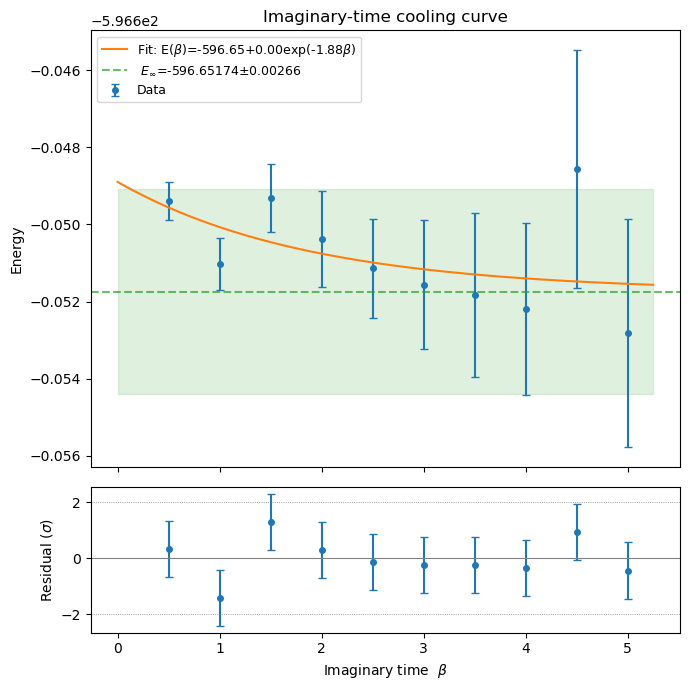

(np.float64(-596.6517379950188), np.float64(0.0026638197277620342))

In [8]:
data = '''
  0.00  -596.63962   0.00452    279.82
  0.50  -596.64939   0.00049    279.83
  1.00  -596.65103   0.00068    279.83
  1.50  -596.64931   0.00088    279.83
  2.00  -596.65038   0.00124    279.83
  2.50  -596.65114   0.00128    279.83
  3.00  -596.65156   0.00167    279.83
  3.50  -596.65183   0.00212    279.83
  4.00  -596.65219   0.00223    279.83
  4.50  -596.64856   0.00308    279.83
  5.00  -596.65282   0.00296    279.83
'''
arr = np.loadtxt(data.strip().splitlines())
tau = arr[1:, 0]
energy = arr[1:, 1]
d_energy = arr[1:, 2]
fit_fp_decay(tau, energy, d_energy, save_plot=False)